In [2]:
# Import required libraries
import pandas as pd
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Improve graph appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Upload dataset manually
uploaded = files.upload()

Saving heart.csv to heart.csv


In [3]:
# Read the uploaded CSV file
df = pd.read_csv(next(iter(uploaded)))

# Display the first five records
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
# Display dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Distribution Analysis

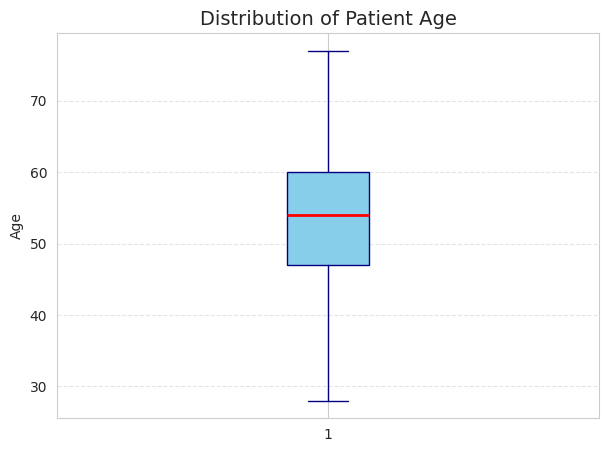

In [6]:
# Create a boxplot for Age
plt.figure(figsize=(7,5))

plt.boxplot(
    df["Age"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="navy"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="navy"),
    capprops=dict(color="navy"),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=6)
)

plt.title("Distribution of Patient Age", fontsize=14)
plt.ylabel("Age")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Relationship Analysis

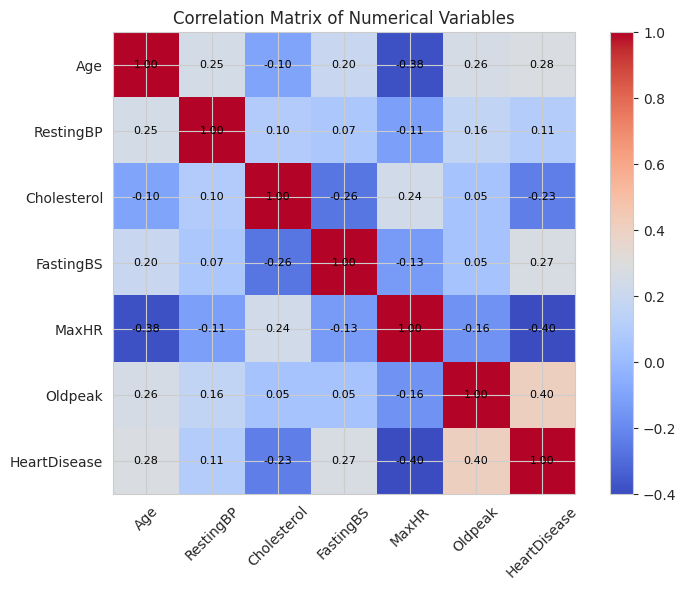

In [7]:
# Select numerical variables
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
corr = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Numerical Variables")

# Display correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=8)

plt.tight_layout()
plt.show()

Categorical Analysis

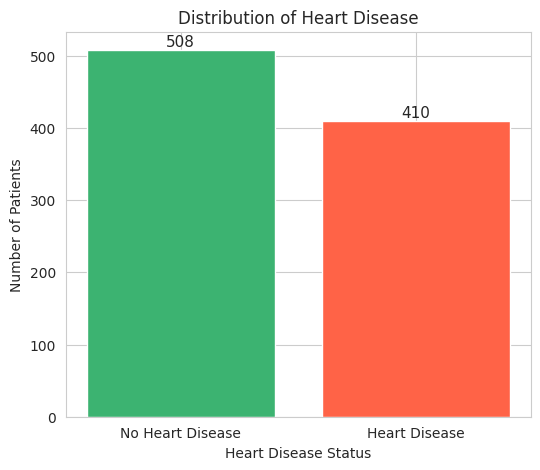

In [8]:
# Count Heart Disease cases
heart_counts = df["HeartDisease"].value_counts()

# Plot bar chart
plt.figure(figsize=(6,5))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    heart_counts.values,
    color=["mediumseagreen", "tomato"]
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

# Display values
for i, value in enumerate(heart_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=11)

plt.show()

Q2

In [9]:
# Check for invalid values

bp_zero = (df["RestingBP"] == 0).sum()
chol_zero = (df["Cholesterol"] == 0).sum()

print("Number of RestingBP values equal to 0:", bp_zero)
print("Number of Cholesterol values equal to 0:", chol_zero)

Number of RestingBP values equal to 0: 1
Number of Cholesterol values equal to 0: 172


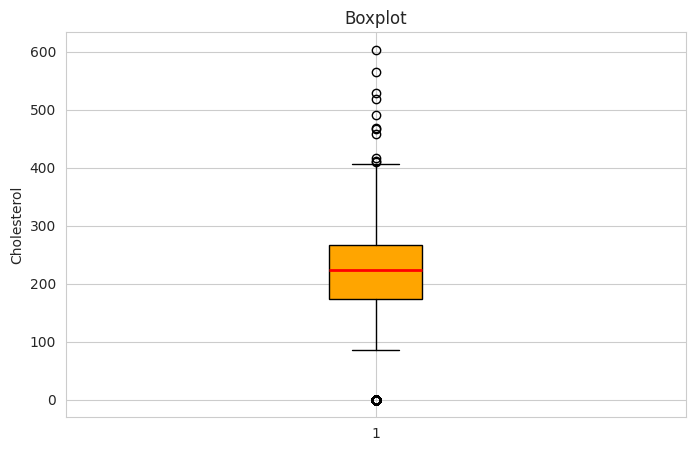

In [11]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["Cholesterol"],
    patch_artist=True,
    boxprops=dict(facecolor="orange"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Boxplot")
plt.ylabel("Cholesterol")

plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
encoder = LabelEncoder()

# List of categorical columns
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

# Apply Label Encoding
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

# Display first five records
df.head()



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.433140,1,1,0.410909,0.825070,0,1,1.382928,0,-0.832432,2,0
1,-0.478484,0,2,1.491752,-0.171961,0,1,0.754157,0,0.105664,1,1
2,-1.751359,1,1,-0.129513,0.770188,0,2,-1.525138,0,-0.832432,2,0
3,-0.584556,0,0,0.302825,0.139040,0,1,-1.132156,1,0.574711,1,1
4,0.051881,1,2,0.951331,-0.034755,0,1,-0.581981,0,-0.832432,2,0


In [17]:
from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

# Create scaler
scaler = StandardScaler()

# Scale numerical variables
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display first five records
df.head()
# Summary statistics after scaling
df[numerical_columns].describe().round(2)

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.71,-7.15,-1.82,-3.02,-3.27
25%,-0.69,-0.67,-0.23,-0.66,-0.83
50%,0.05,-0.13,0.22,0.05,-0.27
75%,0.69,0.41,0.62,0.75,0.57
max,2.49,3.65,3.70,2.56,4.98


In [18]:
# Define features and target variable

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [19]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (734, 11)
Testing Set: (184, 11)


In [20]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model

baseline_model = LogisticRegression(random_state=42)

# Train model

baseline_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [21]:
# Predict testing data

y_pred = baseline_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1-Score :", round(f1,4))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy : 0.8696
Precision: 0.8482
Recall   : 0.9314
F1-Score : 0.8879
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        82
           1       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



Q2 B

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10,None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [35]:
# Best Random Forest model
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, random_state=42)

In [36]:
y_pred_rf = best_rf.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(accuracy_rf,4))
print("Precision:", round(precision_rf,4))
print("Recall   :", round(recall_rf,4))
print("F1-Score :", round(f1_rf,4))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9022
Precision: 0.9038
Recall   : 0.9216
F1-Score : 0.9126
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



Q3

In [4]:
def validate_dataset(df):
    print("Automated Data Validation Results")
    print("---------------------------------")

    # Check missing values
    missing_values = df.isnull().sum().sum()

    # Check duplicate rows
    duplicate_rows = df.duplicated().sum()

    # Check invalid values
    invalid_restingbp = (df["RestingBP"] == 0).sum()
    invalid_cholesterol = (df["Cholesterol"] == 0).sum()

    print("Total Missing Values:", missing_values)
    print("Duplicate Rows:", duplicate_rows)
    print("Invalid RestingBP values:", invalid_restingbp)
    print("Invalid Cholesterol values:", invalid_cholesterol)

    if missing_values == 0 and duplicate_rows == 0:
        print("Basic validation passed.")
    else:
        print("Basic validation failed.")

# Run validation
validate_dataset(df)

Automated Data Validation Results
---------------------------------
Total Missing Values: 0
Duplicate Rows: 0
Invalid RestingBP values: 1
Invalid Cholesterol values: 172
Basic validation passed.
